***Artificial Intelligence and Machine Learning.
Implementation of Convolutional Neural Network using Keras.***

***Task 1: Data Understanding & Visualization***

***Check Structure***

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import random
from sklearn.metrics import classification_report

In [21]:
from google.colab import files
uploaded = files.upload()

import zipfile

with zipfile.ZipFile("FruitinAmazon.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

Saving FruitinAmazon.zip to FruitinAmazon (1).zip


In [22]:
base_dir = "/content/dataset/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")

In [23]:
class_names = os.listdir(train_dir)
print("Classes:", class_names)

Classes: ['graviola', 'guarana', 'acai', 'tucuma', 'pupunha', 'cupuacu']


***Display one image from each class***

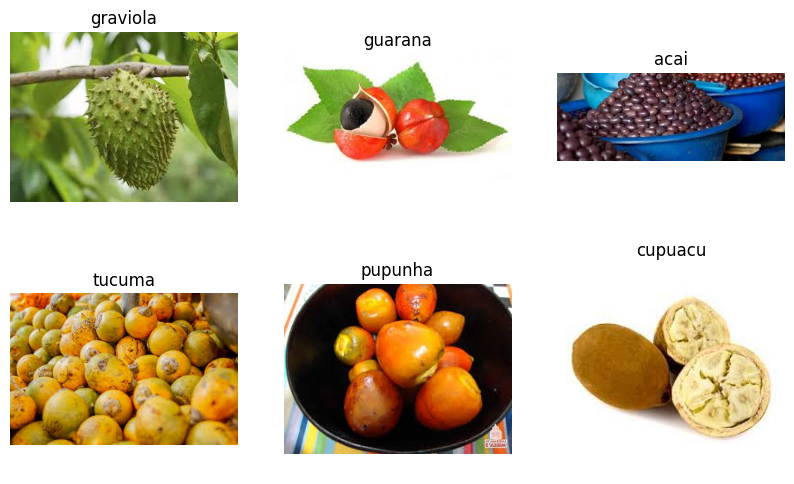

In [24]:
plt.figure(figsize=(10,6))

for i, class_name in enumerate(class_names[:6]):  # 6 images
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [25]:
corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print("Removed:", img_path)

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


***Task 2: Load & Preprocess Data***

In [26]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

In [27]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [28]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

***Task 3: Build CNN Model***

In [29]:
num_classes = len(class_names)

model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


***Task 4: Compile Model***

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

***Task 5: Train Model***

In [31]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.1846 - loss: 2.0531

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 718ms/step - accuracy: 0.1944 - loss: 2.1484 - val_accuracy: 0.3333 - val_loss: 1.8809
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.3003 - loss: 2.0217

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 592ms/step - accuracy: 0.2917 - loss: 1.9968 - val_accuracy: 0.2778 - val_loss: 1.7068
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 659ms/step - accuracy: 0.3889 - loss: 1.5465 - val_accuracy: 0.1111 - val_loss: 1.8803
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.3183 - loss: 1.4636

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 563ms/step - accuracy: 0.3611 - loss: 1.4169 - val_accuracy: 0.2222 - val_loss: 1.5742
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.6944 - loss: 1.0973 - val_accuracy: 0.2778 - val_loss: 1.8454
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.6806 - loss: 0.9329 - val_accuracy: 0.2778 - val_loss: 1.6730
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 448ms/step - accuracy: 0.8194 - loss: 0.6865 - val_accuracy: 0.3889 - val_loss: 1.6422
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.8056 - loss: 0.6032 - val_accuracy: 0.4444 - val_loss: 1.8097
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9253 - loss: 0.3449

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 929ms/step - accuracy: 0.9167 - loss: 0.3756 - val_accuracy: 0.5000 - val_loss: 1.5391
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.8889 - loss: 0.3285 - val_accuracy: 0.3889 - val_loss: 1.6140
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 0.9722 - loss: 0.1749 - val_accuracy: 0.4444 - val_loss: 2.3608
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 478ms/step - accuracy: 0.9861 - loss: 0.1679 - val_accuracy: 0.3889 - val_loss: 2.0084
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 442ms/step - accuracy: 1.0000 - loss: 0.0775 - val_accuracy: 0.4444 - val_loss: 1.5524
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 1.0000 - loss: 0.0456

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 509ms/step - accuracy: 1.0000 - loss: 0.0458 - val_accuracy: 0.5000 - val_loss: 1.4432
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 474ms/step - accuracy: 1.0000 - loss: 0.0312 - val_accuracy: 0.4444 - val_loss: 1.5555
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 643ms/step - accuracy: 1.0000 - loss: 0.0152 - val_accuracy: 0.3889 - val_loss: 1.8744
Epoch 17/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.3333 - val_loss: 2.2114
Epoch 18/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.3889 - val_loss: 2.3602
Epoch 19/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 441ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 0.3889 - val_loss: 2.3150


***Task 6: Evaluate Model***

In [32]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.3889 - loss: 2.3150
Accuracy: 0.3888888955116272


***Task 7: Save & Load Model***

In [33]:
model.save("final_model.h5")

loaded_model = keras.models.load_model("final_model.h5")

***Predictions + Classification Report***

In [34]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
              precision    recall  f1-score   support

    graviola       0.33      1.00      0.50         1
     guarana       0.17      0.50      0.25         2
        acai       1.00      0.67      0.80         3
      tucuma       0.67      0.40      0.50         5
     pupunha       0.00      0.00      0.00         4
     cupuacu       0.25      0.33      0.29         3

    accuracy                           0.39        18
   macro avg       0.40      0.48      0.39        18
weighted avg       0.43      0.39      0.38        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
              precision    recall  f1-score   support

    graviola       0.33      1.00      0.50         1
     guarana       0.17      0.50      0.25         2
        acai       1.00      0.67      0.80         3
      tucuma       0.67      0.40      0.50         5
     pupunha       0.00      0.00      0.00         4
     cupuacu       0.25      0.33      0.29         3

    accuracy                           0.39        18
   macro avg       0.40      0.48      0.39        18
weighted avg       0.43      0.39      0.38        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#***Week6***

***CNN FROM scratch***

# ***Building an End-to-End Image Classifier with CNNs.***

In [36]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


#Check Corrupted Images

In [39]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()
        except:
            corrupted_images.append(img_path)

print("Corrupted Images:", corrupted_images)

Corrupted Images: []


#Class Distribution

In [40]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.endswith(('.jpg','.png','.jpeg'))]
    class_counts[class_name] = len(images)

print(class_counts)

{'graviola': 15, 'guarana': 15, 'acai': 15, 'tucuma': 15, 'pupunha': 15, 'cupuacu': 15}


#Load Dataset (Train + Validation)

In [41]:
import tensorflow as tf
from tensorflow import keras

image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


#Data Augmentation

In [42]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

#Build CNN Model (Task-1)

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    layers.Input(shape=(224,224,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    Conv2D(32, (3,3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(128, (3,3), padding='same'),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),

    Dense(128),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),

    Dense(len(class_names), activation='softmax')
])

#Compile & Train

In [44]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.2778 - loss: 2.2621 - val_accuracy: 0.2222 - val_loss: 1.6815
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5972 - loss: 1.1814 - val_accuracy: 0.0556 - val_loss: 1.8756
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.6250 - loss: 1.1841 - val_accuracy: 0.1667 - val_loss: 1.6989
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.5972 - loss: 1.0397 - val_accuracy: 0.2778 - val_loss: 1.6406
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.8056 - loss: 0.6693 - val_accuracy: 0.2222 - val_loss: 1.6183
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.7361 - loss: 0.8932 - val_accuracy: 0.2222 - val_loss: 1.7146
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.6667 - loss: 1.0211 - val_accuracy: 0.2222 - val_loss: 1.8054
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.5694 - loss: 1.1210 - val_accuracy: 0.2222 - val_loss: 1.8612
Epoch 9/

#Evaluate

In [45]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step - accuracy: 0.2222 - loss: 1.8262


[1.826249599456787, 0.2222222238779068]

#TASK-2: Transfer Learning
***Load Pretrained Model***

In [46]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Freeze Layers

In [47]:
for layer in base_model.layers:
    layer.trainable = False

#Add Custom Layers

In [48]:
from tensorflow.keras.layers import GlobalAveragePooling2D

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
outputs = Dense(len(class_names), activation='softmax')(x)

#Final Model

In [49]:
from tensorflow.keras.models import Model

model_vgg = Model(inputs=base_model.input, outputs=outputs)

#Compile & Train

In [50]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 16s/step - accuracy: 0.2639 - loss: 6.4737 - val_accuracy: 0.1667 - val_loss: 5.3292
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.5278 - loss: 2.6632 - val_accuracy: 0.3333 - val_loss: 4.1264
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 15s/step - accuracy: 0.8611 - loss: 0.4302 - val_accuracy: 0.2778 - val_loss: 4.4896
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 16s/step - accuracy: 0.9028 - loss: 0.2219 - val_accuracy: 0.2778 - val_loss: 5.8648
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 15s/step - accuracy: 0.9167 - loss: 0.2200 - val_accuracy: 0.2778 - val_loss: 5.9844


#Predictions

In [51]:
import numpy as np

for images, labels in val_ds.take(1):
    preds = model_vgg.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

print(predicted_labels)
print(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
[0 2 1 3 2 2 2 3 3 3 0 4 4 3 3 2 3 2]
[4 4 1 5 1 0 1 5 3 0 0 4 5 5 5 2 4 1]


#Classification Report

In [52]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vgg.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
              precision    recall  f1-score   support

    graviola       0.50      0.33      0.40         3
     guarana       1.00      0.25      0.40         4
        acai       0.17      1.00      0.29         1
      tucuma       0.14      1.00      0.25         1
     pupunha       0.50      0.25      0.33         4
     cupuacu       0.00      0.00      0.00         5

    accuracy                           0.28        18
   macro avg       0.38      0.47      0.28        18
weighted avg       0.43      0.28      0.26        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
